<a href="https://colab.research.google.com/github/kheirbeqaya/segmentation-and-pose-estimation-using-grabcut-and-pca/blob/main/segmentation_and_pose_estimation_using_grabcut_and_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python numpy scikit-image
import math
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

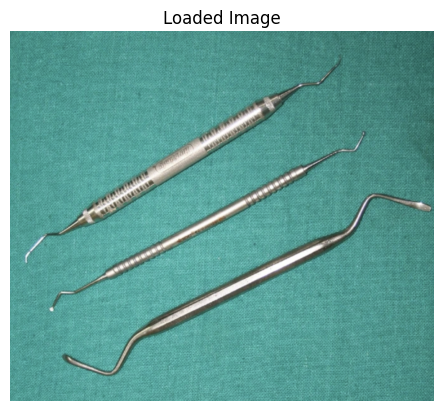

In [2]:
url ="https://raw.githubusercontent.com/kheirbeqaya/segmentation-and-pose-estimation-using-grabcut-and-pca/main/data/images/LucasCurette_SpoonExcavator_Peridontal_Curette.png"
#url = "https://raw.githubusercontent.com/kheirbeqaya/segmentation-and-pose-estimation-using-grabcut-and-pca/main/data/images/dental_tools.jpg"

resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
image = cv2.imdecode(image, cv2.IMREAD_COLOR)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Loaded Image")
plt.axis("off")
plt.show()



In [3]:
#for the first image
#x1, y1 = 50, 85
#x2, y2 = 80, 278

#for the second image
#x1, y1 = 140, 500
#x2, y2 = 1330, 1100
#for the second image
x1, y1 = 400, 500
x2, y2 = 1100, 1100

bbox = (x1, y1, x2 - x1, y2 - y1)

print("bbox:", bbox)


bbox: (400, 500, 700, 600)


In [4]:
img_vis = image.copy()

x, y, w, h = bbox
cv2.rectangle(img_vis, (x, y), (x+w, y+h), (0, 255, 0), 2)

#plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
#plt.title("Selected ROI")
#plt.axis("off")
#plt.show()

array([[[126, 136,  68],
        [121, 131,  64],
        [120, 130,  63],
        ...,
        [ 86,  93,  43],
        [ 84,  91,  41],
        [ 89,  95,  44]],

       [[125, 135,  68],
        [125, 135,  68],
        [125, 135,  67],
        ...,
        [ 91,  96,  45],
        [ 89,  95,  44],
        [ 93,  98,  46]],

       [[123, 133,  66],
        [125, 136,  68],
        [126, 136,  69],
        ...,
        [ 95,  99,  48],
        [ 94,  99,  47],
        [ 96, 101,  49]],

       ...,

       [[159, 166,  89],
        [155, 162,  84],
        [152, 159,  83],
        ...,
        [136, 148,  80],
        [140, 151,  82],
        [130, 139,  74]],

       [[159, 166,  89],
        [149, 156,  80],
        [145, 152,  76],
        ...,
        [134, 143,  77],
        [138, 147,  80],
        [130, 138,  73]],

       [[153, 158,  82],
        [137, 144,  71],
        [132, 138,  66],
        ...,
        [133, 140,  75],
        [134, 140,  76],
        [130, 137,  73]]

In [5]:
mask = np.full(image.shape[:2], cv2.GC_PR_BGD, np.uint8)

# sure background outside bbox
mask[:y, :] = cv2.GC_BGD
mask[y+h:, :] = cv2.GC_BGD
mask[:, :x] = cv2.GC_BGD
mask[:, x+w:] = cv2.GC_BGD

# small sure foreground region
cx1 = x + int(w * 0.4)
cx2 = x + int(w * 0.6)
cy1 = y + int(h * 0.4)
cy2 = y + int(h * 0.6)

mask[cy1:cy2, cx1:cx2] = cv2.GC_FGD

bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

In [6]:
cv2.grabCut(
    image,
    mask,
    None,
    bgdModel,
    fgdModel,
    15,
    cv2.GC_INIT_WITH_MASK
)

mask2 = np.where(
    (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD),
    1,
    0
).astype("uint8")

In [7]:
kernel = np.ones((7,7), np.uint8)

mask2 = cv2.morphologyEx(mask2, cv2.MORPH_CLOSE, kernel, iterations=2)
mask2 = cv2.morphologyEx(mask2, cv2.MORPH_OPEN, kernel, iterations=1)

contours, _ = cv2.findContours(mask2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

largest_contour = max(contours, key=cv2.contourArea)

clean_mask = np.zeros_like(mask2)
cv2.drawContours(clean_mask, [largest_contour], -1, 1, -1)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [8]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])

green_mask = cv2.inRange(hsv, lower_green, upper_green)
non_green = cv2.bitwise_not(green_mask)

final_mask = cv2.bitwise_and(clean_mask, clean_mask, mask=non_green)

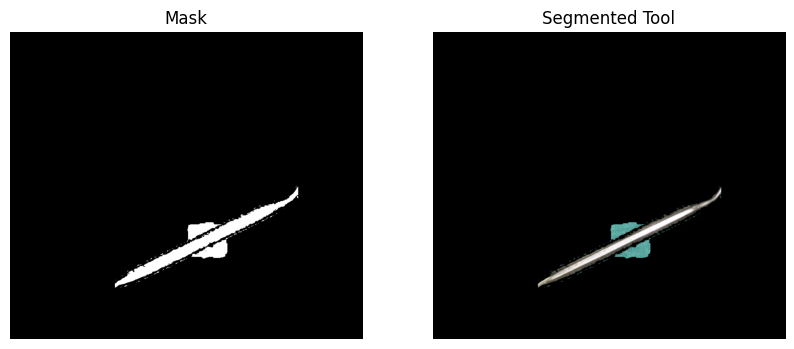

In [9]:
segmented = image * final_mask[:, :, np.newaxis]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Mask")
plt.imshow(final_mask, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Segmented Tool")
plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

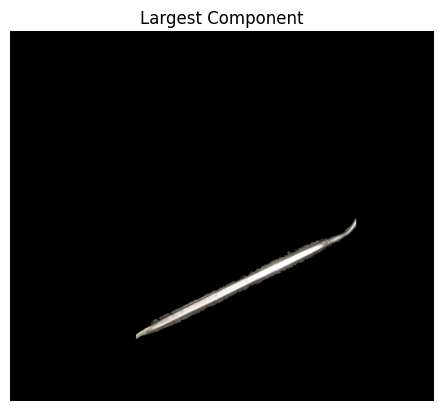

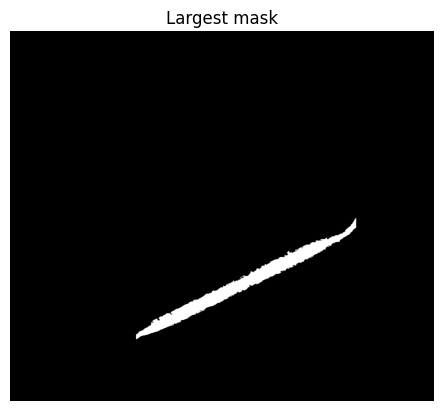

In [10]:
num_labels, labels = cv2.connectedComponents(final_mask)

max_label = 1
max_size = 0

for i in range(1, num_labels):
    size = np.sum(labels == i)
    if size > max_size:
        max_size = size
        max_label = i

largest_mask = (labels == max_label).astype("uint8")

component_img = image * largest_mask[:, :, np.newaxis]
#largest_mask = largest_mask * 255
plt.imshow(cv2.cvtColor(component_img, cv2.COLOR_BGR2RGB))
plt.title("Largest Component")
plt.axis("off")
plt.show()
plt.imshow(largest_mask,cmap='gray')
plt.title("Largest mask")
plt.axis("off")
plt.show()

In [11]:
# extract the contour of the largest mask
contours, _ = cv2.findContours(largest_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

# calculate the max contour
cnt = max(contours, key=cv2.contourArea)

# convert it to coordinate shape
coords = cnt.reshape(-1, 2).astype(np.float32)

#reduce the coordinate

coords = coords[::5]

# PCA
if len(coords) > 10:

    mean, eigenvectors = cv2.PCACompute(coords, mean=None)

    vx, vy = eigenvectors[0]

    center = tuple(mean[0].astype(int))

    # normalize
    norm = np.sqrt(vx**2 + vy**2)
    vx, vy = vx/norm, vy/norm

    angle = np.degrees(np.arctan2(vy, vx))
    if angle < 0:
        angle += 180

    print("Angle:", angle)

    # draw
    L = 200
    x2 = int(center[0] - vx * L)
    y2 = int(center[1] - vy * L)

    img_angle = image.copy()

    cv2.circle(img_angle, center, 5, (0,255,0), -1)
    cv2.line(img_angle, center, (x2, y2), (0,0,255), 3)

    h, w = image.shape[:2]
    cv2.line(img_angle,
         (center[0] , center[1]),
         (center[0] + L, center[1]),
         (255,0,0), 2)
    #plt.imshow(cv2.cvtColor(img_angle, cv2.COLOR_BGR2RGB))
    #plt.title(f"Contour PCA Angle = {angle:.2f}°")
    #plt.axis("off")
    #plt.show()

Angle: 153.58948


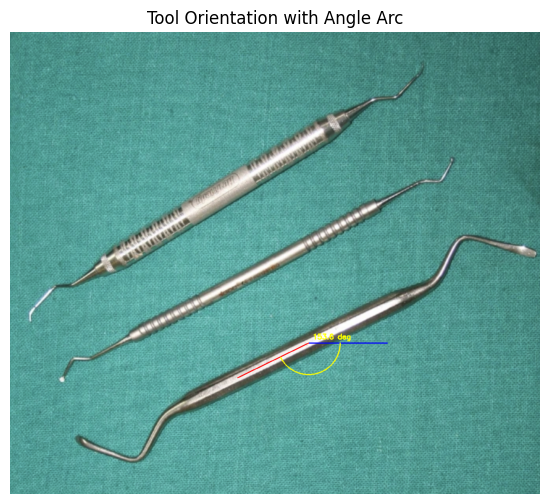

In [12]:
img_arc = image.copy()

# center of the object (from PCA)
cx, cy = center

# radius of arc
r = 80

# angle from PCA (in degrees)
theta = angle

startAngle = 0
endAngle = int(theta)

# normalize angle to valid range [0, 180]
if endAngle < 0:
    endAngle += 180

# reference line (0° direction - horizontal axis)
cv2.line(img_arc,
         (cx, cy),
         (cx + 200, cy),
         (255, 0, 0), 2)

# PCA direction (tool main axis)
cv2.line(img_arc,
         (cx, cy),
         (x2, y2),
         (0, 0, 255), 2)

# draw angle arc between reference and PCA direction
cv2.ellipse(img_arc,
            (cx, cy),
            (r, r),
            0,
            startAngle,
            endAngle,
            (0, 255, 255),
            2)

cv2.putText(img_arc,
            f"{angle:.1f} deg",
            (cx + 10, cy - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 255),
            2)


plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img_arc, cv2.COLOR_BGR2RGB))
plt.title("Tool Orientation with Angle Arc")
plt.axis("off")
plt.show()